# 📚 Data Mining Final Project
## Computer Science Journal Finder

**Amaç:** Bir araştırmacı makalesinin abstract metnini girdiğinde, o makale için en uygun **Top 5 bilgisayar bilimi dergisini** öneren bir sistem geliştirmek.

**Veri Seti:** 175+ CS dergisinden yayımlanmış 23.000+ makale (Web of Science)

**Metodoloji:**
1. Metin Ön İşleme (Text Preprocessing)
2. TF-IDF Vektörizasyonu
3. Cosine Similarity ile Journal Finder
4. K-Means ile Topic Clustering
5. LDA ile Topic Modelling

---

## Bölüm 1: Kütüphanelerin Yüklenmesi

Projede kullanılacak tüm Python kütüphaneleri burada import edilmektedir:
- **sqlite3 / pandas**: Veritabanından veri okuma
- **nltk**: Doğal dil işleme (stopword temizleme, stemming)
- **sklearn**: TF-IDF, K-Means, SVD, cosine similarity
- **matplotlib / seaborn / wordcloud**: Görselleştirme
- **gensim**: LDA topic modelling

In [1]:
# ── Temel kütüphaneler ──────────────────────────────────────────────────────
import sqlite3
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── Doğal Dil İşleme ───────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ── Makine Öğrenmesi ───────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.preprocessing import normalize

# ── Görselleştirme ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


---
## Bölüm 2: Veritabanı Bağlantısı ve Veri Yükleme

SQLite veritabanına bağlanılarak 4 tablo birleştiriliyor:
- `AcademicRecord`: Her makaleye ait temel bilgiler
- `AcademicRecordAbstract`: Abstract metinleri
- `Publication`: Dergi adları
- `AcademicRecordKeyword`: Yazar tarafından verilen anahtar kelimeler

Her makale için tek bir satır elde etmek amacıyla abstract ve keywords birleştirilerek `combined_text` sütunu oluşturulmaktadır.

In [ ]:
# ── Veritabanı bağlantısı ──────────────────────────────────────────────────
# Not: Dosya yolunu kendi bilgisayarınıza göre güncelleyin
DB_PATH = '/Users/nazligonca/Desktop/journal_finder/data/CompSciencePub.sqlite'   # ← kendi path'inizi yazın
conn = sqlite3.connect(DB_PATH)

# ── Makale + Abstract + Dergi adı sorgusu ──────────────────────────────────
query_main = """
    SELECT 
        ar.AcademicRecordID,
        ar.PublicationId,
        p.Name        AS JournalName,
        p.ISSN,
        ar.PubYear,
        ar.Title,
        ara.AbstractText
    FROM AcademicRecord ar
    JOIN AcademicRecordAbstract ara 
         ON ar.AcademicRecordID = ara.AcademicRecordId
    JOIN Publication p 
         ON ar.PublicationId = p.PublicationID
    WHERE ara.AbstractText IS NOT NULL
      AND TRIM(ara.AbstractText) != ''
"""
df = pd.read_sql(query_main, conn)

# ── Yazar anahtar kelimeleri (keyword boost için) ────────────
query_kw = """
    SELECT ark.AcademicRecordId, GROUP_CONCAT(ak.Name, ' ') AS Keywords
    FROM AcademicRecordKeyword ark
    JOIN AcademicKeyword ak ON ark.AcademicKeywordId = ak.AcademicKeywordID
    GROUP BY ark.AcademicRecordId
"""
df_kw = pd.read_sql(query_kw, conn)

# ── İki tabloyu birleştir ───────────────────────
df = df.merge(df_kw, left_on='AcademicRecordID', right_on='AcademicRecordId', how='left')
df['Keywords'] = df['Keywords'].fillna('')

# Abstract + Keywords birleşik metin (keywords 2x ağırlıklı)
df['combined_text'] = df['AbstractText'] + ' ' + df['Keywords'] + ' ' + df['Keywords']

conn.close()
print(f"✅ Toplam makale sayısı    : {len(df):,}")
print(f"✅ Toplam dergi sayısı     : {df['JournalName'].nunique():,}")
print(f"✅ Yıl aralığı             : {df['PubYear'].min()} – {df['PubYear'].max()}")

✅ Toplam makale sayısı    : 23,061
✅ Toplam dergi sayısı     : 455
✅ Yıl aralığı             : 2000 – 2018


In [6]:
# ── Veri setine genel bakış ────────────────────────────────────────────────
# İlk 3 satırı görüntüle (Abstract sütununu kısa tutalım)
preview = df[['AcademicRecordID','JournalName','PubYear','Title']].head(3)
display(preview)

# Dergi başına makale dağılımı
journal_counts = df['JournalName'].value_counts()
print("\n📊 En fazla makaleye sahip 10 dergi:")
display(journal_counts.head(10).reset_index().rename(
    columns={'index':'Journal', 'JournalName':'Makale Sayısı'}))

,AcademicRecordID,JournalName,PubYear,Title
0,88652,ACM COMPUTING SURVEYS,2000,An updated survey of GA-based multiobjective o...
1,88653,ACM COMPUTING SURVEYS,2000,The state of the art in distributed query proc...
2,88654,ACM COMPUTING SURVEYS,2000,Logical models of argument



📊 En fazla makaleye sahip 10 dergi:


,Makale Sayısı,count
0,ACM COMPUTING SURVEYS,76
1,ACM TRANSACTIONS ON DATABASE SYSTEMS,76
2,ACM TRANSACTIONS ON DESIGN AUTOMATION OF ELECT...,76
3,ACM TRANSACTIONS ON GRAPHICS,76
4,ACM TRANSACTIONS ON INFORMATION SYSTEMS,76
5,ACTA INFORMATICA,76
6,ARTIFICIAL INTELLIGENCE,76
7,ARTIFICIAL INTELLIGENCE REVIEW,76
8,CMES-COMPUTER MODELING IN ENGINEERING & SCIENCES,76
9,COMPUTATIONAL GEOSCIENCES,76


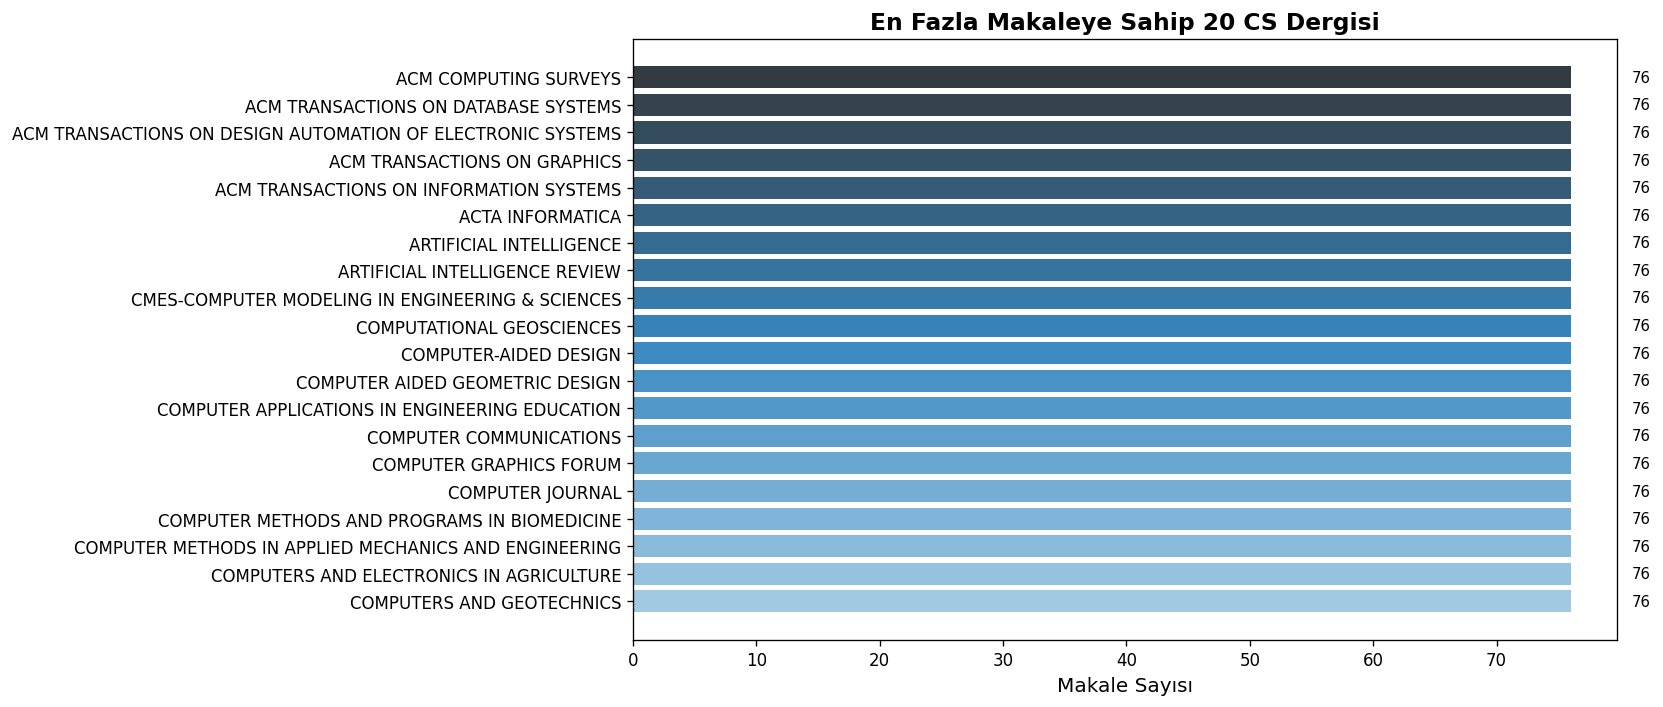

💾 Grafik kaydedildi: output_fig1_journal_distribution.png


In [7]:
# ── Dergi başına makale sayısı – bar chart ─────────────────────────────────
top20 = journal_counts.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=sns.color_palette('Blues_d', 20))
ax.set_xlabel('Makale Sayısı', fontsize=12)
ax.set_title('En Fazla Makaleye Sahip 20 CS Dergisi', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output_fig1_journal_distribution.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig1_journal_distribution.png")

---
## Bölüm 3: Metin Ön İşleme (Text Preprocessing)

Ham abstract metinleri model için kullanılabilir hale getirmek amacıyla aşağıdaki adımlar uygulanmaktadır:

1. **HTML etiketlerini temizle** → `<p>`, `<b>` gibi etiketler kaldırılır
2. **Küçük harfe çevir** → Büyük/küçük harf farkı ortadan kalkar
3. **Sayı ve noktalama işaretlerini kaldır**
4. **Stopword temizleme** → "the", "is", "of" gibi anlamsız kelimeler çıkarılır
5. **Stemming** → "running" → "run", "algorithms" → "algorithm" (Porter Stemmer)
6. **Çok kısa kelimeleri at** → 2 harften kısa kelimeler anlamsız

In [8]:
# ── Metin temizleme fonksiyonu ─────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess(text: str) -> str:
    """Ham metni temizler ve normalize eder."""
    # 1. HTML etiketlerini kaldır
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Küçük harfe çevir
    text = text.lower()
    # 3. Sadece harf ve boşluk bırak
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Çoklu boşlukları teke indir
    text = re.sub(r'\s+', ' ', text).strip()
    # 5. Tokenize, stopword ve kısa kelime filtresi + stemming
    tokens = [
        stemmer.stem(w)
        for w in text.split()
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

# ── Tüm metinlere uygula (birkaç dakika sürebilir) ─────────────────────────
print("⏳ Metinler işleniyor...")
df['clean_text'] = df['combined_text'].apply(preprocess)
print("✅ Ön işleme tamamlandı.")

# ── Örnek: Ham vs Temiz metin ──────────────────────────────────────────────
print("\n📝 Ham abstract (ilk 300 karakter):")
print(df['AbstractText'].iloc[0][:300])
print("\n🔧 Temizlenmiş metin (ilk 300 karakter):")
print(df['clean_text'].iloc[0][:300])

⏳ Metinler işleniyor...
✅ Ön işleme tamamlandı.

📝 Ham abstract (ilk 300 karakter):
<p>After using evolutionary techniques for single-objective optimization during more than two decades, the incorporation of more than one objective in the fitness function has finally become a popular area of research. As a consequence, many new evolutionary-based approaches and variations of existi

🔧 Temizlenmiş metin (ilk 300 karakter):
use evolutionari techniqu singl object optim two decad incorpor one object fit function final becom popular area research consequ mani new evolutionari base approach variat exist techniqu recent publish technic literatur purpos paper summar organ inform current approach emphas import analyz oper res


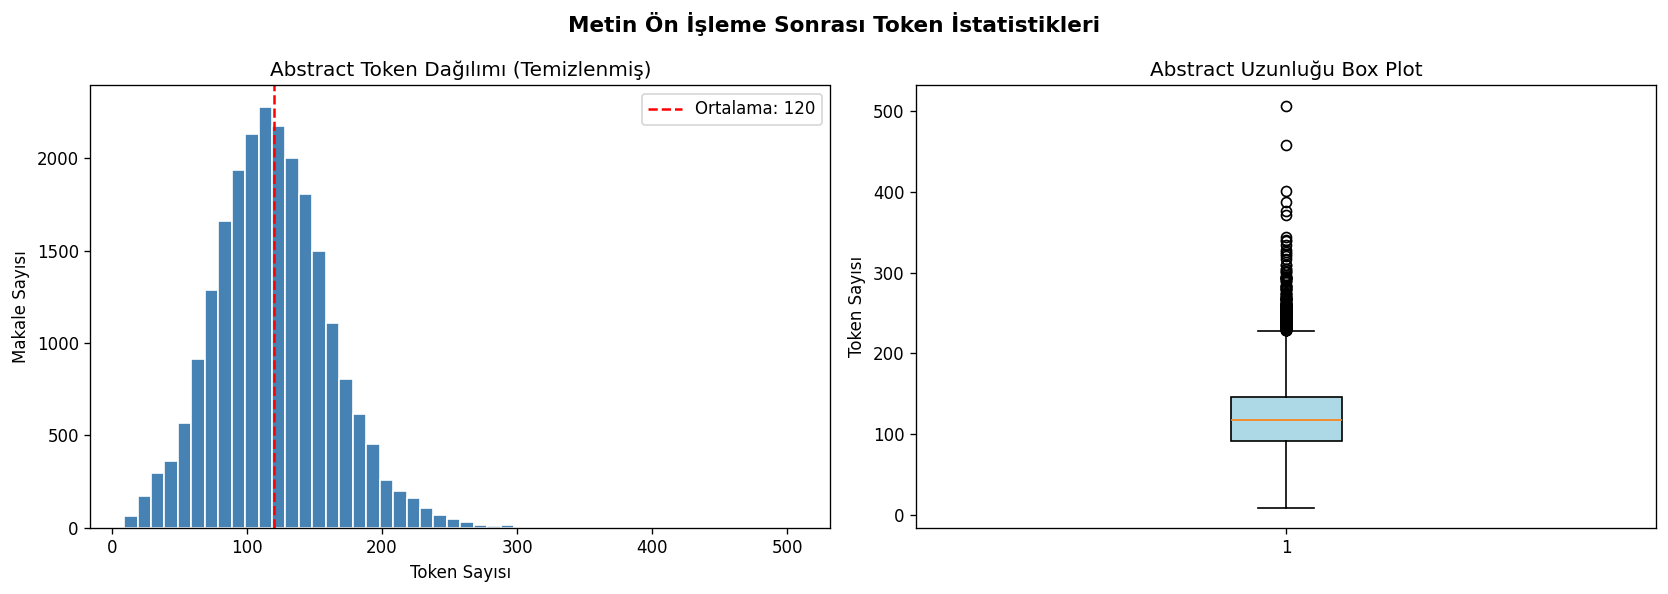

📊 Ortalama token sayısı : 120.1
📊 Medyan token sayısı  : 118.0
📊 Min token sayısı     : 9
📊 Max token sayısı     : 507


In [9]:
# ── Token istatistikleri ───────────────────────────────────────────────────
df['token_count'] = df['clean_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['token_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Token Sayısı')
axes[0].set_ylabel('Makale Sayısı')
axes[0].set_title('Abstract Token Dağılımı (Temizlenmiş)')
axes[0].axvline(df['token_count'].mean(), color='red', linestyle='--',
                label=f'Ortalama: {df["token_count"].mean():.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['token_count'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_ylabel('Token Sayısı')
axes[1].set_title('Abstract Uzunluğu Box Plot')

plt.suptitle('Metin Ön İşleme Sonrası Token İstatistikleri', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_fig2_token_distribution.png', bbox_inches='tight')
plt.show()

print(f"📊 Ortalama token sayısı : {df['token_count'].mean():.1f}")
print(f"📊 Medyan token sayısı  : {df['token_count'].median():.1f}")
print(f"📊 Min token sayısı     : {df['token_count'].min()}")
print(f"📊 Max token sayısı     : {df['token_count'].max()}")

---
## Bölüm 4: TF-IDF Vektörizasyonu

**TF-IDF (Term Frequency – Inverse Document Frequency):** Her kelimenin bir belgede ne kadar önemli olduğunu sayısal olarak ölçer.

$$TF\text{-}IDF(t,d) = TF(t,d) \times \log\frac{N}{df(t)}$$

- **TF:** Kelimenin o belgede geçme sıklığı
- **IDF:** Kelimenin tüm belgeler arasında ne kadar nadir olduğu
- **max_features=10000:** En sık geçen 10.000 kelime seçilir
- **ngram_range=(1,2):** Tek kelime ve ikili kelime öbekleri (bigrams) kullanılır
- **min_df=2:** En az 2 belgede geçen kelimeler dahil edilir

In [10]:
# ── TF-IDF matrisi oluştur ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=10000,    # En önemli 10.000 özellik
    ngram_range=(1, 2),    # Unigram + bigram
    min_df=2,              # En az 2 belgede geçmeli
    max_df=0.95,           # Çok yaygın (>%95) kelimeler atılır
    sublinear_tf=True      # TF'ye log ölçekleme uygulanır
)

print("⏳ TF-IDF matrisi oluşturuluyor...")
tfidf_matrix = tfidf.fit_transform(df['clean_text'])
print(f"✅ TF-IDF matrisi boyutu : {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]:,} makale  ×  {tfidf_matrix.shape[1]:,} özellik")
print(f"   → Matris yoğunluğu  : {tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.4%}")

# ── En yüksek TF-IDF ağırlıklı ilk 20 kelime ──────────────────────────────
feature_names = tfidf.get_feature_names_out()
mean_scores   = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top20_idx     = mean_scores.argsort()[::-1][:20]

print("\n🔑 En yüksek ortalama TF-IDF skoruna sahip 20 kelime:")
top20_df = pd.DataFrame({
    'Kelime': feature_names[top20_idx],
    'Ortalama TF-IDF Skoru': mean_scores[top20_idx]
})
display(top20_df)

⏳ TF-IDF matrisi oluşturuluyor...
✅ TF-IDF matrisi boyutu : (23061, 10000)
   → 23,061 makale  ×  10,000 özellik
   → Matris yoğunluğu  : 0.8461%

🔑 En yüksek ortalama TF-IDF skoruna sahip 20 kelime:


,Kelime,Ortalama TF-IDF Skoru
0,use,0.022217
1,model,0.022102
2,system,0.021983
3,base,0.019471
4,algorithm,0.019372
5,network,0.019216
6,data,0.018462
7,comput,0.017887
8,method,0.017588
9,propos,0.017367


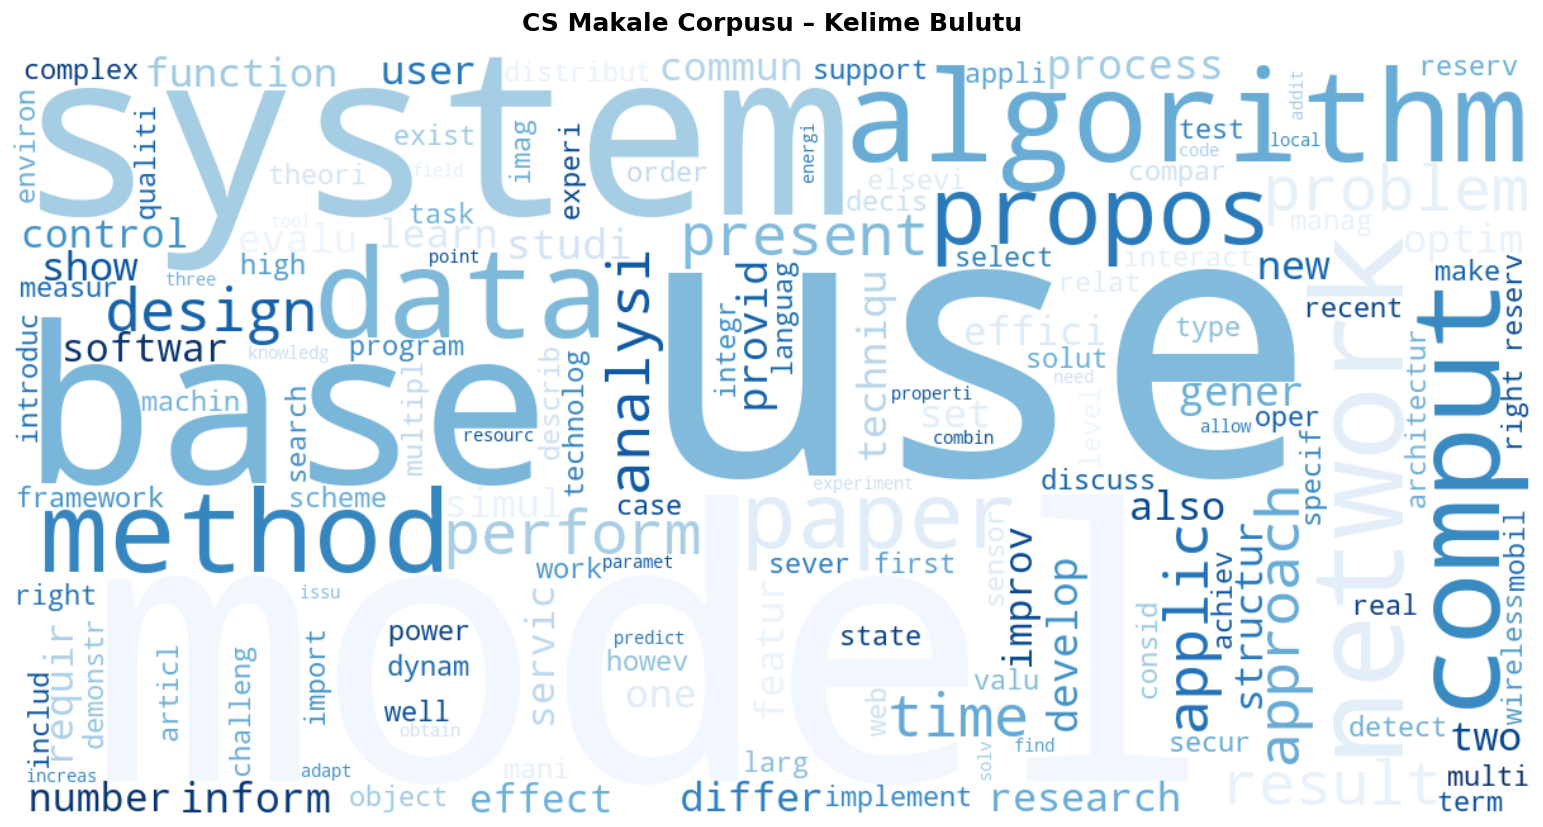

💾 Grafik kaydedildi: output_fig3_wordcloud.png


In [11]:
# ── Tüm corpus için Word Cloud ─────────────────────────────────────────────
word_freq = dict(zip(feature_names[top20_idx[:100]], mean_scores[top20_idx[:100]]))

# Geniş kelime frekans dict'i
all_top = 200
top_all_idx = mean_scores.argsort()[::-1][:all_top]
word_freq_all = dict(zip(feature_names[top_all_idx], mean_scores[top_all_idx]))

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=150
).generate_from_frequencies(word_freq_all)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('CS Makale Corpusu – Kelime Bulutu', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('output_fig3_wordcloud.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig3_wordcloud.png")

---
## Bölüm 5: Journal Finder – Cosine Similarity

**Yöntem:** Kullanıcının girdiği abstract, TF-IDF ile vektörleştirilir. Bu vektörün veritabanındaki tüm makale vektörleriyle cosine similarity'si hesaplanır. Her dergi için o dergiye ait makalelerin ortalama benzerlik skoru alınarak sıralama yapılır.

$$\cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$$

- 0 → tamamen alakasız
- 1 → tamamen benzer

In [15]:
# ── Dergi düzeyinde TF-IDF vektörü oluştur ────────────────────────────────
# Her derginin tüm makalelerinin ortalama TF-IDF vektörünü hesapla
# Bu sayede sorgu anında daha hızlı çalışır

journals        = df['JournalName'].values
unique_journals = df['JournalName'].unique()

journal_vectors = {}
for j in unique_journals:
    mask = journals == j
    # ✅ np.asarray ile np.matrix → ndarray dönüşümü yapılıyor
    journal_vectors[j] = np.asarray(tfidf_matrix[mask].mean(axis=0)).flatten()

journal_names_list = list(journal_vectors.keys())
journal_matrix     = np.vstack([journal_vectors[j] for j in journal_names_list])

print(f"✅ Dergi vektör matrisi boyutu: {journal_matrix.shape}")
print(f"   → {journal_matrix.shape[0]} dergi  ×  {journal_matrix.shape[1]:,} özellik")

✅ Dergi vektör matrisi boyutu: (455, 10000)
   → 455 dergi  ×  10,000 özellik


In [16]:
# ── Journal Finder Ana Fonksiyonu ──────────────────────────────────────────
def find_top_journals(abstract_text: str, top_n: int = 5) -> pd.DataFrame:
    """
    Verilen abstract metnine göre en uygun N dergiyi döndürür.

    Parametreler:
        abstract_text : Kullanıcının girdiği ham abstract metni
        top_n         : Kaç dergi döndürüleceği (varsayılan 5)

    Dönüş:
        pd.DataFrame : JournalName, Similarity Score, Makale Sayısı
    """
    # 1. Metni temizle ve vektörleştir
    clean    = preprocess(abstract_text)
    query_v  = tfidf.transform([clean])

    # 2. Tüm dergi vektörleriyle cosine similarity hesapla
    scores   = cosine_similarity(query_v, journal_matrix).flatten()

    # 3. En yüksek N skoru seç
    top_idx  = scores.argsort()[::-1][:top_n]

    # 4. Sonuçları düzenle
    results  = pd.DataFrame({
        'Sıra'          : range(1, top_n + 1),
        'Dergi Adı'     : [journal_names_list[i] for i in top_idx],
        'Benzerlik Skoru': [round(scores[i], 4) for i in top_idx],
        'Makale Sayısı' : [
            df[df['JournalName'] == journal_names_list[i]].shape[0]
            for i in top_idx
        ]
    })
    return results

print("✅ find_top_journals() fonksiyonu hazır.")

✅ find_top_journals() fonksiyonu hazır.


🔍 TEST 1 – Derin Öğrenme / Görüntü İşleme


,Sıra,Dergi Adı,Benzerlik Skoru,Makale Sayısı
0,1,NEUROCOMPUTING,0.2792,75
1,2,NEURAL PROCESSING LETTERS,0.2464,76
2,3,IEEE JOURNAL OF BIOMEDICAL AND HEALTH INFORMATICS,0.2409,24
3,4,IET COMPUTER VISION,0.2307,48
4,5,COMPUTER VISION AND IMAGE UNDERSTANDING,0.2205,76


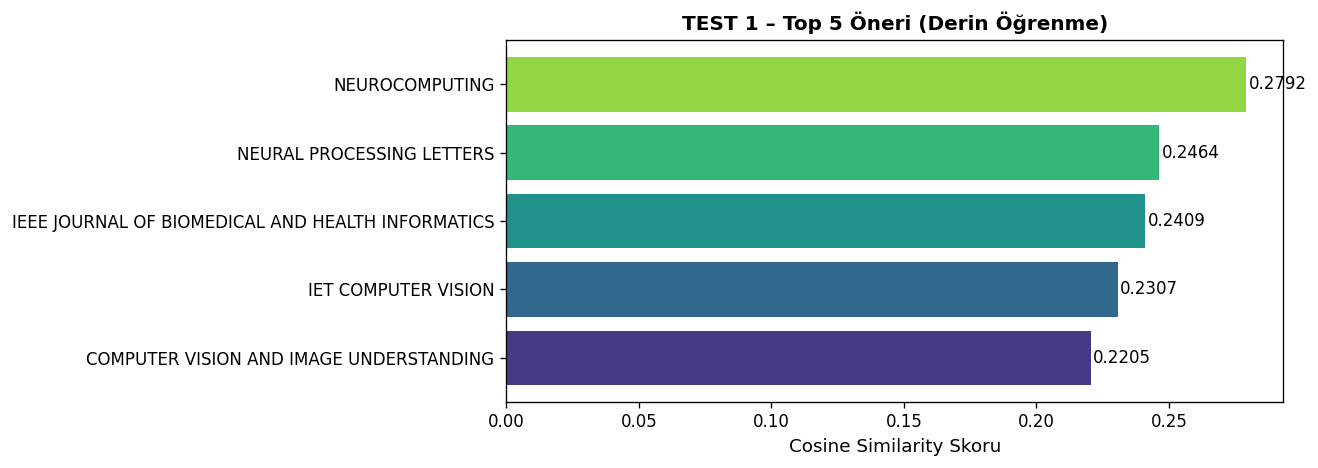

In [17]:
# ── TEST 1: Makine Öğrenmesi konulu abstract ───────────────────────────────
test_abstract_1 = """
We propose a novel deep learning framework for image classification using
convolutional neural networks. The model incorporates attention mechanisms
and residual connections to improve feature extraction. Experiments on
benchmark datasets (CIFAR-10, ImageNet) demonstrate that our approach
achieves state-of-the-art accuracy while reducing training time by 30%.
The proposed method generalizes well across various computer vision tasks.
"""

print("🔍 TEST 1 – Derin Öğrenme / Görüntü İşleme")
print("="*60)
result1 = find_top_journals(test_abstract_1, top_n=5)
display(result1)

# ── Görselleştirme ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
colors  = sns.color_palette('viridis', len(result1))
bars    = ax.barh(result1['Dergi Adı'][::-1], result1['Benzerlik Skoru'][::-1], color=colors)
ax.set_xlabel('Cosine Similarity Skoru', fontsize=11)
ax.set_title('TEST 1 – Top 5 Öneri (Derin Öğrenme)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, result1['Benzerlik Skoru'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=10)
plt.tight_layout()
plt.savefig('output_fig4_test1_results.png', bbox_inches='tight')
plt.show()

🔍 TEST 2 – Ağ Güvenliği / Siber Saldırı Tespiti


,Sıra,Dergi Adı,Benzerlik Skoru,Makale Sayısı
0,1,COMPUTERS & SECURITY,0.2085,74
1,2,JOURNAL OF MACHINE LEARNING RESEARCH,0.2079,72
2,3,INTERNATIONAL ARAB JOURNAL OF INFORMATION TECH...,0.2062,43
3,4,MALAYSIAN JOURNAL OF COMPUTER SCIENCE,0.1976,44
4,5,JOURNAL OF NETWORK AND SYSTEMS MANAGEMENT,0.1943,52


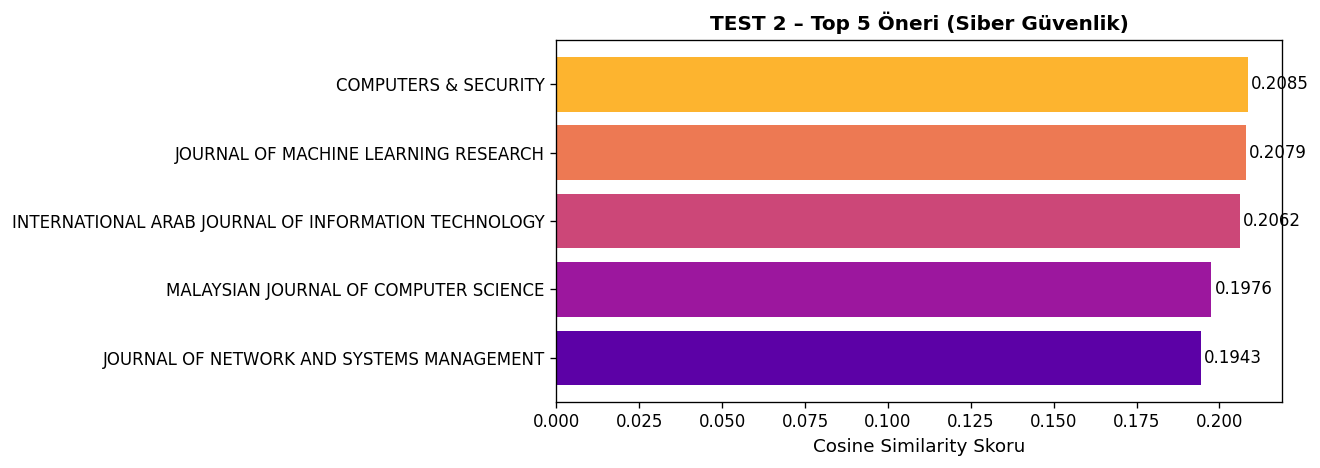

In [18]:
# ── TEST 2: Ağ güvenliği konulu abstract ──────────────────────────────────
test_abstract_2 = """
This paper presents an intrusion detection system based on machine learning
techniques to identify network anomalies and cyber attacks in real-time.
We use a combination of random forest and support vector machines to classify
network traffic. The system is evaluated on the NSL-KDD dataset and achieves
99.1% detection rate with a false positive rate below 0.5%.
"""

print("🔍 TEST 2 – Ağ Güvenliği / Siber Saldırı Tespiti")
print("="*60)
result2 = find_top_journals(test_abstract_2, top_n=5)
display(result2)

fig, ax = plt.subplots(figsize=(11, 4))
colors  = sns.color_palette('plasma', len(result2))
bars    = ax.barh(result2['Dergi Adı'][::-1], result2['Benzerlik Skoru'][::-1], color=colors)
ax.set_xlabel('Cosine Similarity Skoru', fontsize=11)
ax.set_title('TEST 2 – Top 5 Öneri (Siber Güvenlik)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, result2['Benzerlik Skoru'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=10)
plt.tight_layout()
plt.savefig('output_fig5_test2_results.png', bbox_inches='tight')
plt.show()

🔍 TEST 3 – Dağıtık Veritabanı / Graf İşleme


,Sıra,Dergi Adı,Benzerlik Skoru,Makale Sayısı
0,1,VLDB JOURNAL,0.2576,76
1,2,DISTRIBUTED AND PARALLEL DATABASES,0.2403,76
2,3,ACM TRANSACTIONS ON DATABASE SYSTEMS,0.2386,76
3,4,SIGMOD RECORD,0.2195,69
4,5,International Journal of Data Warehousing and ...,0.1887,1


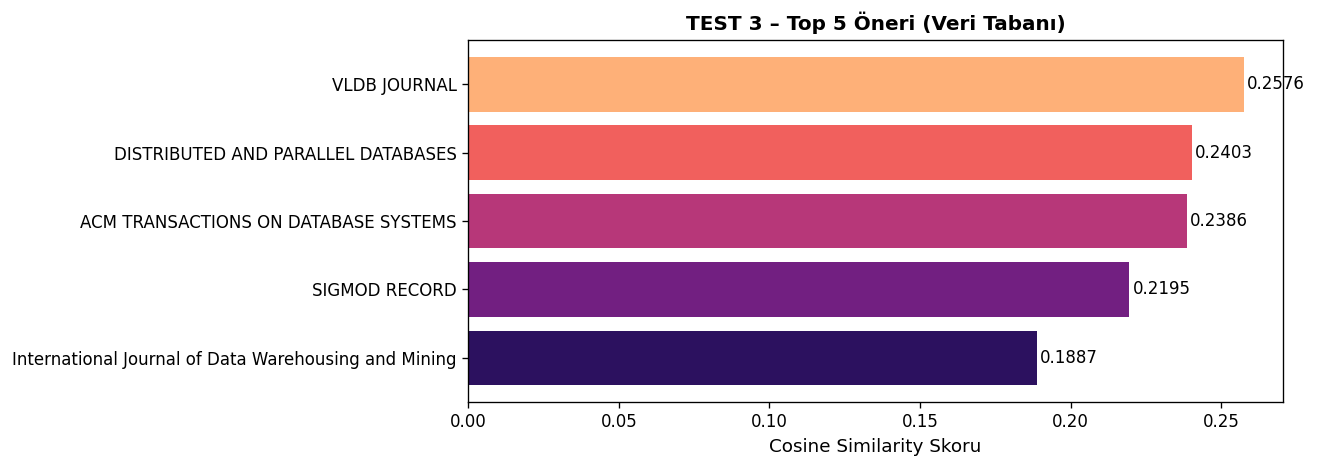

In [19]:
# ── TEST 3: Veri tabanı / Dağıtık sistemler ───────────────────────────────
test_abstract_3 = """
We introduce a distributed database management system optimized for
large-scale graph data processing. Our system employs a novel query
optimization algorithm that reduces latency by partitioning graph
workloads across multiple nodes. Benchmarks show 5x throughput improvement
over existing systems on social network graph queries.
"""

print("🔍 TEST 3 – Dağıtık Veritabanı / Graf İşleme")
print("="*60)
result3 = find_top_journals(test_abstract_3, top_n=5)
display(result3)

fig, ax = plt.subplots(figsize=(11, 4))
colors  = sns.color_palette('magma', len(result3))
bars    = ax.barh(result3['Dergi Adı'][::-1], result3['Benzerlik Skoru'][::-1], color=colors)
ax.set_xlabel('Cosine Similarity Skoru', fontsize=11)
ax.set_title('TEST 3 – Top 5 Öneri (Veri Tabanı)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, result3['Benzerlik Skoru'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=10)
plt.tight_layout()
plt.savefig('output_fig6_test3_results.png', bbox_inches='tight')
plt.show()

---
## Bölüm 6: Topic Clustering – K-Means

**Amaç:** CS dergilerinin hangi konu kümelerinde toplandığını keşfetmek.

**Yöntem:**
1. TF-IDF matrisi 50 boyuta indirgenir (**Truncated SVD** / LSA)
2. **K-Means** ile kümeler oluşturulur
3. En iyi K sayısı **Elbow Method** ile belirlenir
4. Kümeler 2D olarak görselleştirilir (SVD → 2 bileşen)

In [20]:
# ── Boyut indirgeme: TF-IDF → 50 boyut (LSA) ──────────────────────────────
print("⏳ SVD boyut indirgeme uygulanıyor...")
svd50 = TruncatedSVD(n_components=50, random_state=42)
X50   = svd50.fit_transform(tfidf_matrix)
X50   = normalize(X50)   # L2 normalize
print(f"✅ Boyut indirgeme tamamlandı: {tfidf_matrix.shape} → {X50.shape}")
print(f"   Açıklanan varyans: {svd50.explained_variance_ratio_.sum():.2%}")

⏳ SVD boyut indirgeme uygulanıyor...
✅ Boyut indirgeme tamamlandı: (23061, 10000) → (23061, 50)
   Açıklanan varyans: 9.67%


⏳ Elbow analizi çalışıyor (K=2..20)...


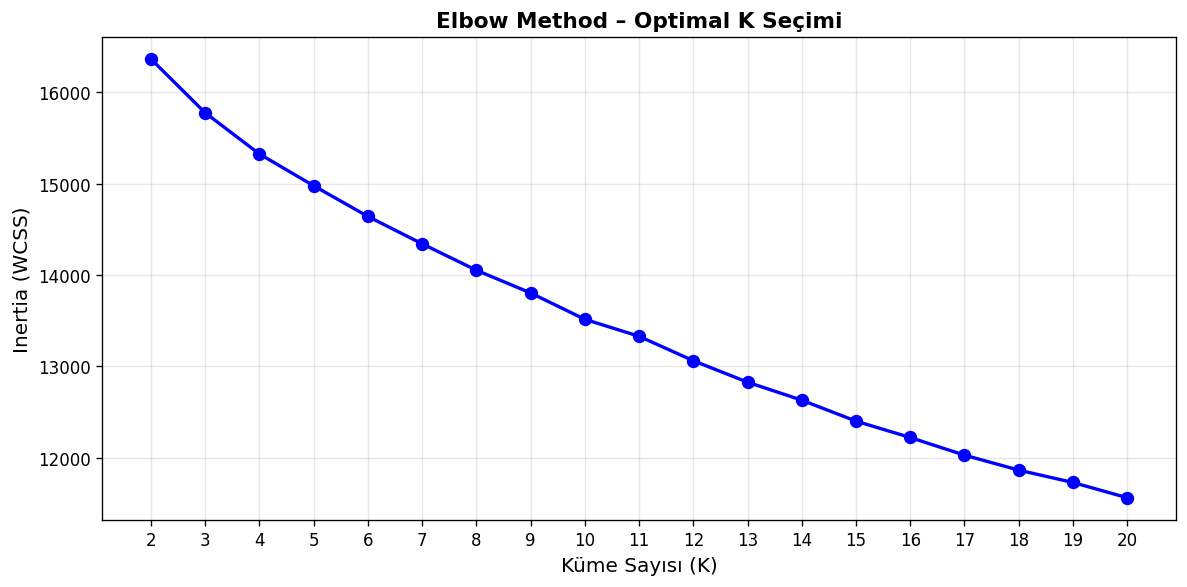

💾 Grafik kaydedildi: output_fig7_elbow.png


In [21]:
# ── Elbow Method: Optimal K seçimi ────────────────────────────────────────
# Her K için inertia (küme içi kare hataları toplamı) hesaplanır
# İnertiada belirgin düşüş yavaşladığı nokta optimal K'dır

inertias = []
K_range  = range(2, 21)

print("⏳ Elbow analizi çalışıyor (K=2..20)...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X50)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Küme Sayısı (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method – Optimal K Seçimi', fontsize=13, fontweight='bold')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output_fig7_elbow.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig7_elbow.png")

In [22]:
# ── K-Means Kümeleme (K=8) ─────────────────────────────────────────────────
# Elbow grafiğinde belirgin kırılmanın göründüğü K değerini kullan
OPTIMAL_K = 8   # ← Elbow grafiğine göre ayarlayın

print(f"⏳ K-Means çalışıyor (K={OPTIMAL_K})...")
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
df['cluster'] = kmeans.fit_predict(X50)
print("✅ Kümeleme tamamlandı.")

# Küme boyutları
cluster_sizes = df['cluster'].value_counts().sort_index()
print("\n📊 Küme Boyutları:")
display(cluster_sizes.reset_index().rename(columns={'index':'Küme', 'cluster':'Makale Sayısı'}))

⏳ K-Means çalışıyor (K=8)...
✅ Kümeleme tamamlandı.

📊 Küme Boyutları:


,Makale Sayısı,count
0,0,2331
1,1,2603
2,2,2591
3,3,5377
4,4,2451
5,5,4149
6,6,1116
7,7,2443


In [23]:
# ── Her kümenin temel anahtar kelimeleri ──────────────────────────────────
print("🏷️  Küme Anahtar Kelimeleri (Top 10):")
print("="*60)

cluster_keywords = {}
feature_names_arr = tfidf.get_feature_names_out()

for cluster_id in range(OPTIMAL_K):
    # O kümedeki makalelerin TF-IDF ortalama vektörü
    cluster_mask = df['cluster'] == cluster_id
    cluster_tfidf_mean = tfidf_matrix[cluster_mask.values].mean(axis=0)
    top_word_idx = np.asarray(cluster_tfidf_mean).flatten().argsort()[::-1][:10]
    keywords     = [feature_names_arr[i] for i in top_word_idx]
    cluster_keywords[cluster_id] = keywords
    print(f"\n🔹 Küme {cluster_id} ({cluster_mask.sum()} makale):")
    print("   " + ', '.join(keywords))

🏷️  Küme Anahtar Kelimeleri (Top 10):

🔹 Küme 0 (2331 makale):
   comput, perform, system, cloud, architectur, parallel, applic, time, design, data

🔹 Küme 1 (2603 makale):
   network, wireless, sensor, sensor network, node, commun, energi, channel, wireless sensor, protocol

🔹 Küme 2 (2591 makale):
   logic, languag, fuzzi, model, program, set, system, formal, semant, theori

🔹 Küme 3 (5377 makale):
   research, system, inform, model, develop, user, use, technolog, studi, web

🔹 Küme 4 (2451 makale):
   algorithm, optim, problem, search, solut, solv, graph, genet, evolutionari, method

🔹 Küme 5 (4149 makale):
   imag, method, data, learn, featur, use, classif, algorithm, base, propos

🔹 Küme 6 (1116 makale):
   secur, attack, authent, scheme, encrypt, key, privaci, protocol, propos, cryptographi

🔹 Küme 7 (2443 makale):
   model, method, equat, simul, numer, use, function, finit, element, surfac


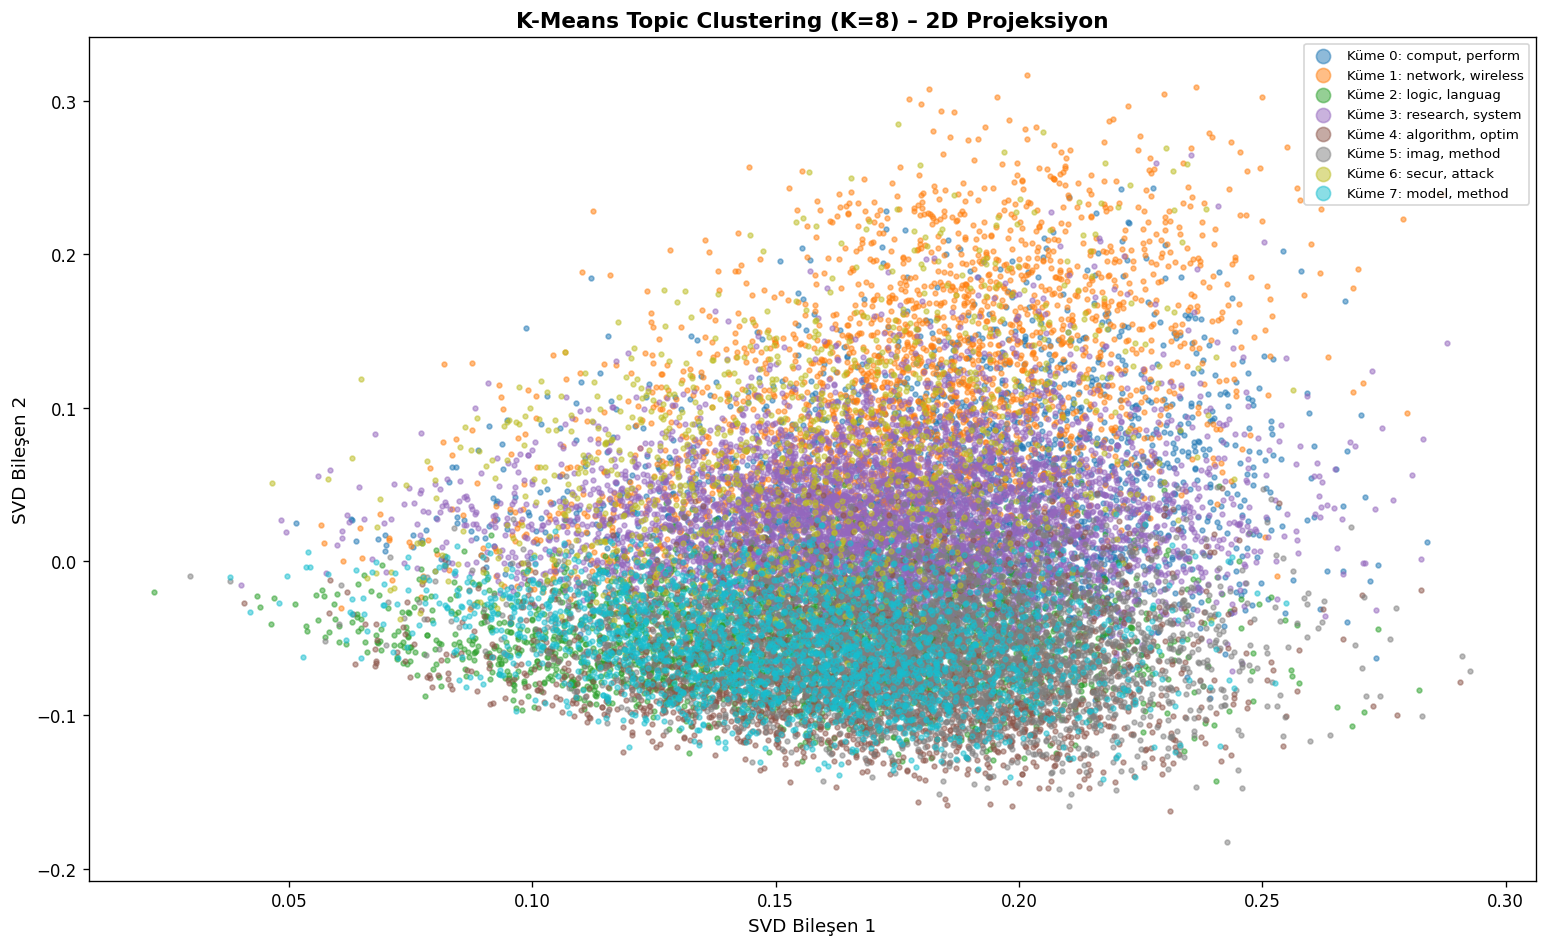

💾 Grafik kaydedildi: output_fig8_clusters_2d.png


In [24]:
# ── 2D Cluster Görselleştirme ─────────────────────────────────────────────
svd2d = TruncatedSVD(n_components=2, random_state=42)
X2d   = svd2d.fit_transform(tfidf_matrix)

colors = cm.get_cmap('tab10', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(13, 8))
for c in range(OPTIMAL_K):
    mask = df['cluster'] == c
    ax.scatter(
        X2d[mask, 0], X2d[mask, 1],
        s=8, alpha=0.5,
        color=colors(c),
        label=f'Küme {c}: {cluster_keywords[c][0]}, {cluster_keywords[c][1]}'
    )

ax.set_xlabel('SVD Bileşen 1', fontsize=11)
ax.set_ylabel('SVD Bileşen 2', fontsize=11)
ax.set_title(f'K-Means Topic Clustering (K={OPTIMAL_K}) – 2D Projeksiyon',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig('output_fig8_clusters_2d.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig8_clusters_2d.png")

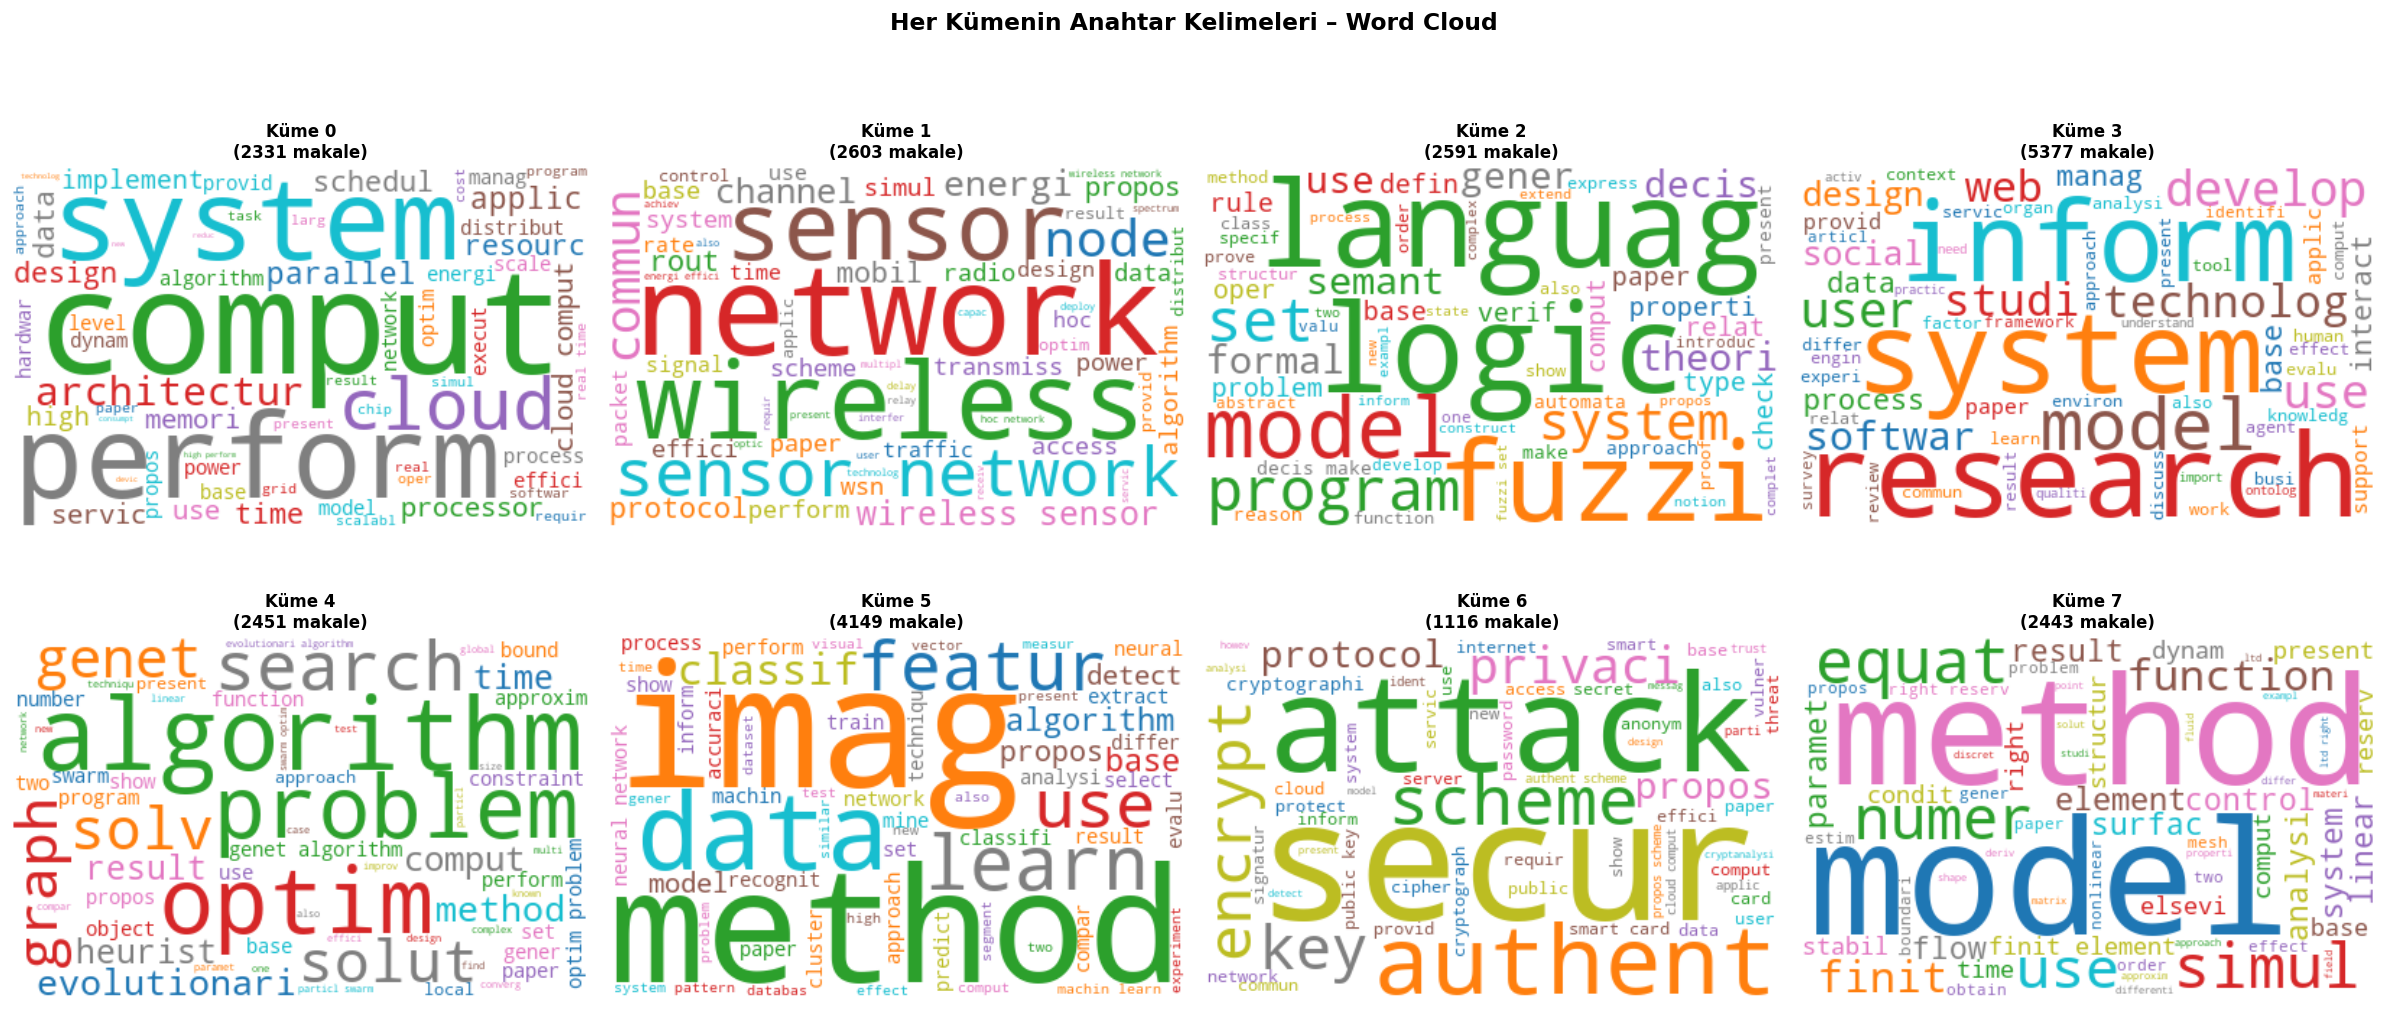

💾 Grafik kaydedildi: output_fig9_cluster_wordclouds.png


In [25]:
# ── Her küme için Word Cloud ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes      = axes.flatten()

for cluster_id in range(OPTIMAL_K):
    cluster_mask = df['cluster'] == cluster_id
    cluster_tfidf_mean = np.asarray(
        tfidf_matrix[cluster_mask.values].mean(axis=0)
    ).flatten()
    top_idx = cluster_tfidf_mean.argsort()[::-1][:80]
    freq    = {feature_names_arr[i]: cluster_tfidf_mean[i] for i in top_idx}

    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap='tab10',
        max_words=60
    ).generate_from_frequencies(freq)

    axes[cluster_id].imshow(wc, interpolation='bilinear')
    axes[cluster_id].axis('off')
    axes[cluster_id].set_title(
        f'Küme {cluster_id}\n({cluster_mask.sum()} makale)',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Her Kümenin Anahtar Kelimeleri – Word Cloud',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_fig9_cluster_wordclouds.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig9_cluster_wordclouds.png")

---
## Bölüm 7: LDA – Konu Modellemesi (Topic Modelling)

**LDA (Latent Dirichlet Allocation):** Her belgeyi, belirli oranlarda konu karışımı olarak modelleyen olasılıksal bir yöntemdir.

- K-Means'tan farkı: Bir makale birden fazla konuya ait olabilir (soft assignment)
- Her konu, belirli kelimelerin dağılımıyla temsil edilir
- Yorumlanabilirliği yüksektir: Konu başlıkları çıkarılabilir

In [26]:
# ── LDA için Count Vectorizer (TF-IDF değil, ham frekanslar gerekir) ───────
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(max_features=5000, min_df=3, max_df=0.90)
X_count   = count_vec.fit_transform(df['clean_text'])

N_TOPICS = 8
print(f"⏳ LDA çalışıyor ({N_TOPICS} konu)... (birkaç dakika sürebilir)")

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)
lda_topics = lda.fit_transform(X_count)
print("✅ LDA tamamlandı.")
print(f"   Log-likelihood: {lda.score(X_count):.2f}")

⏳ LDA çalışıyor (8 konu)... (birkaç dakika sürebilir)
✅ LDA tamamlandı.
   Log-likelihood: -18527387.24


In [27]:
# ── LDA Konularının Kelime Dağılımı ───────────────────────────────────────
cv_feature_names = count_vec.get_feature_names_out()

def get_topic_label(topic_idx: int, n_words: int = 8) -> str:
    """Bir LDA konusunun top kelimelerini döndürür."""
    top_word_ids = lda.components_[topic_idx].argsort()[::-1][:n_words]
    return ', '.join(cv_feature_names[i] for i in top_word_ids)

print("🧩 LDA Konu Dağılımları:")
print("="*70)
for i in range(N_TOPICS):
    print(f"\n📌 Konu {i}: {get_topic_label(i)}")

🧩 LDA Konu Dağılımları:

📌 Konu 0: system, develop, use, research, design, softwar, learn, interact

📌 Konu 1: method, imag, use, model, function, result, estim, linear

📌 Konu 2: inform, model, fuzzi, decis, set, use, social, studi

📌 Konu 3: servic, secur, comput, system, cloud, mobil, user, applic

📌 Konu 4: model, system, use, program, languag, gener, test, process

📌 Konu 5: network, sensor, energi, wireless, node, neural, perform, power

📌 Konu 6: algorithm, optim, problem, time, perform, comput, graph, schedul

📌 Konu 7: data, featur, use, base, learn, classif, detect, imag


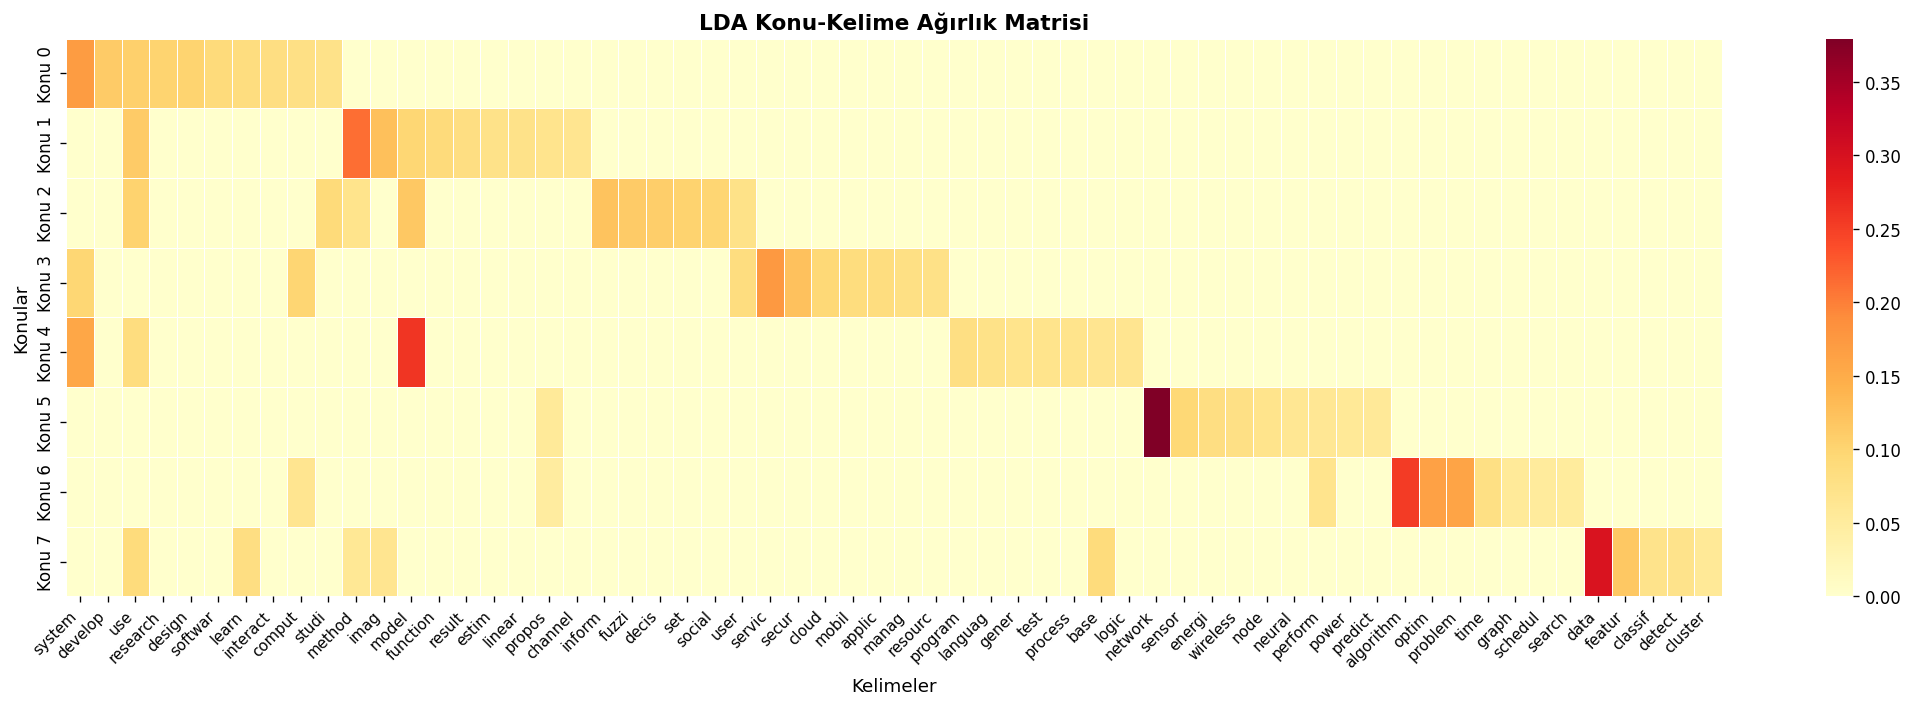

💾 Grafik kaydedildi: output_fig10_lda_heatmap.png


In [28]:
# ── LDA Konu Ağırlıkları – Isı Haritası ──────────────────────────────────
# Her konunun top 10 kelimesini ısı haritasıyla göster

n_top_words = 10
topic_word_matrix = []
top_words_per_topic = []

for i in range(N_TOPICS):
    top_ids   = lda.components_[i].argsort()[::-1][:n_top_words]
    top_words = [cv_feature_names[j] for j in top_ids]
    top_vals  = lda.components_[i][top_ids]
    top_vals  = top_vals / top_vals.sum()   # Normalize
    topic_word_matrix.append(top_vals)
    top_words_per_topic.append(top_words)

# Tüm unique kelimeleri birleştir (ısı haritası için)
all_top_words = list(dict.fromkeys([w for lst in top_words_per_topic for w in lst]))

heatmap_data = np.zeros((N_TOPICS, len(all_top_words)))
for i in range(N_TOPICS):
    word_weight = dict(zip(top_words_per_topic[i], topic_word_matrix[i]))
    for j, w in enumerate(all_top_words):
        heatmap_data[i, j] = word_weight.get(w, 0)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    xticklabels=all_top_words,
    yticklabels=[f'Konu {i}' for i in range(N_TOPICS)],
    cmap='YlOrRd', linewidths=0.3, ax=ax
)
ax.set_title('LDA Konu-Kelime Ağırlık Matrisi', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelimeler', fontsize=11)
ax.set_ylabel('Konular', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('output_fig10_lda_heatmap.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig10_lda_heatmap.png")

---
## Bölüm 8: Dergi – Konu İlişkisi

Her derginin hangi konulara ağırlık verdiğini analiz ediyoruz. Bu, hem "Topic Clustering" çıktısı hem de sistemi anlamlandırmak için önemli bir görseldir.

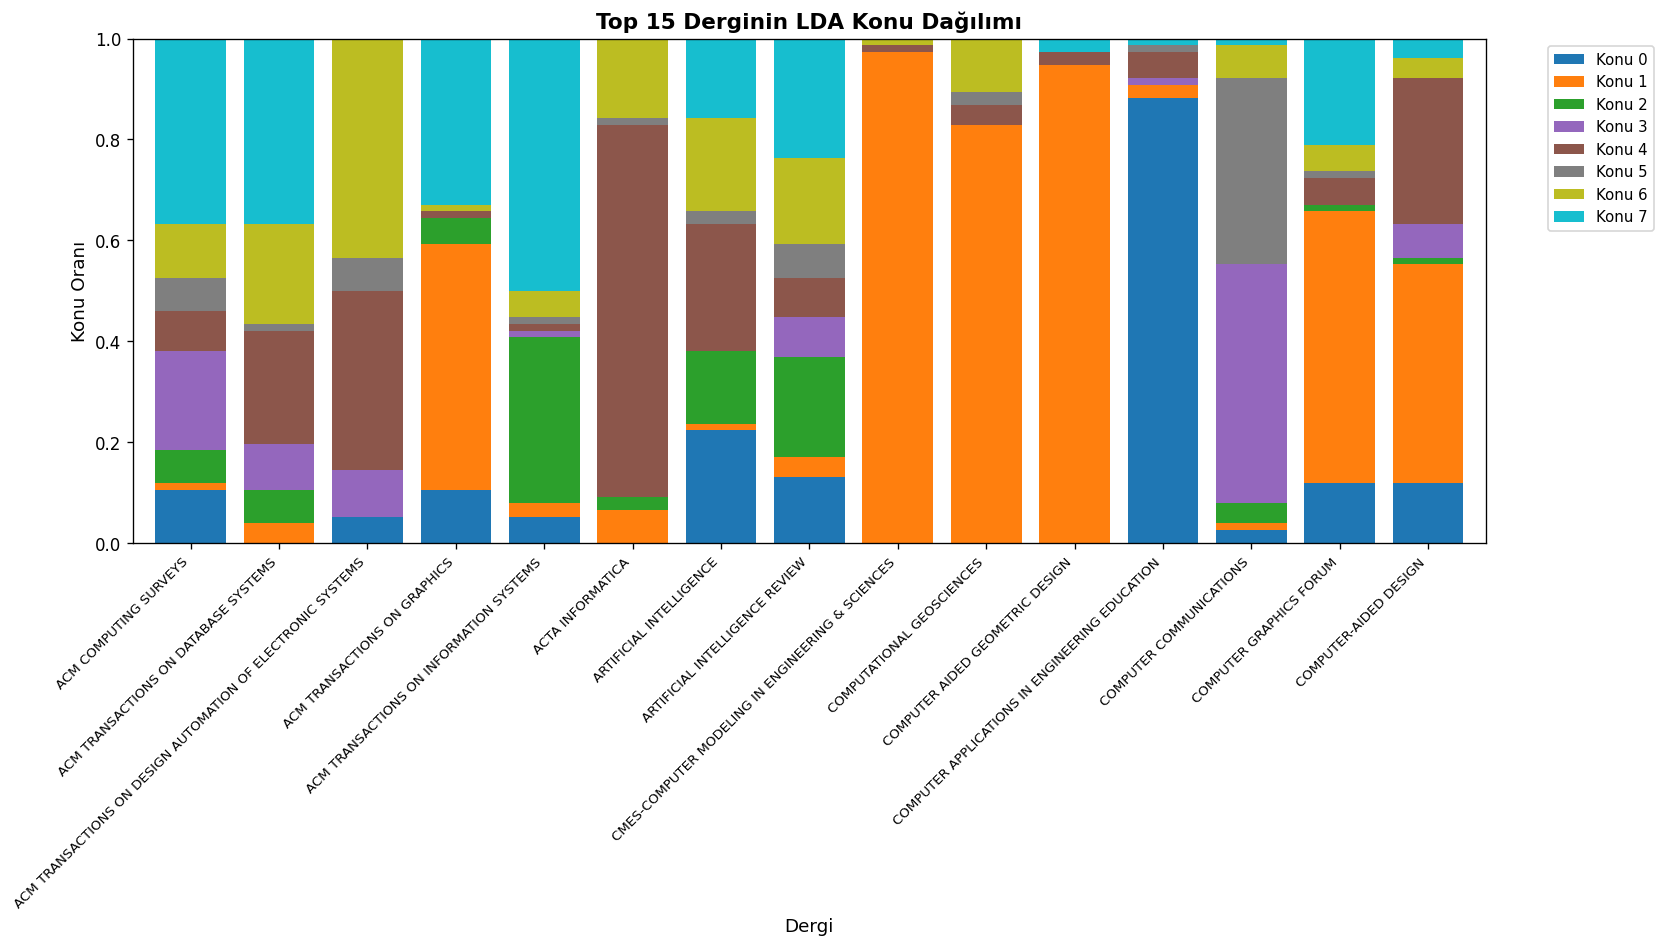

💾 Grafik kaydedildi: output_fig11_journal_topic_dist.png


In [29]:
# ── Her makaleye baskın LDA konusunu ata ──────────────────────────────────
df['lda_topic'] = lda_topics.argmax(axis=1)

# ── Top 15 derginin konu dağılımı ─────────────────────────────────────────
top15_journals = df['JournalName'].value_counts().head(15).index
df_top15       = df[df['JournalName'].isin(top15_journals)]

pivot = pd.crosstab(
    df_top15['JournalName'],
    df_top15['lda_topic'],
    normalize='index'   # Satır yüzdesi (toplam 1.0)
)
pivot.columns = [f'Konu {c}' for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 8))
pivot.plot(
    kind='bar', stacked=True,
    colormap='tab10', ax=ax,
    width=0.8
)
ax.set_xlabel('Dergi', fontsize=11)
ax.set_ylabel('Konu Oranı', fontsize=11)
ax.set_title('Top 15 Derginin LDA Konu Dağılımı', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.13, 1), fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('output_fig11_journal_topic_dist.png', bbox_inches='tight')
plt.show()
print("💾 Grafik kaydedildi: output_fig11_journal_topic_dist.png")

---
## Bölüm 9: Özet ve Sonuçlar

Bu bölümde projenin tüm adımları özetlenmekte ve model performansı değerlendirilmektedir.

In [30]:
# ── Proje Özet Tablosu ────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Bileşen': [
        'Veri Seti', 'Dergi Sayısı', 'Abstract Sayısı',
        'TF-IDF Özellik Sayısı', 'Boyut İndirgeme',
        'K-Means Küme Sayısı', 'LDA Konu Sayısı',
        'Journal Finder Yöntemi'
    ],
    'Değer / Açıklama': [
        'Web of Science – CS Journals',
        f'{df["JournalName"].nunique()}',
        f'{len(df):,}',
        f'{tfidf_matrix.shape[1]:,} (unigram + bigram)',
        f'TruncatedSVD → 50 boyut (açıklanan varyans: {svd50.explained_variance_ratio_.sum():.1%})',
        f'K={OPTIMAL_K} (Elbow Method)',
        f'{N_TOPICS}',
        'Cosine Similarity (Dergi Ortalama TF-IDF Vektörü)'
    ]
})

print("📋 PROJE ÖZET TABLOSU")
print("="*60)
display(summary)

print("\n✅ Proje başarıyla tamamlandı!")
print("📁 Kaydedilen grafikler:")
import glob
for f in sorted(glob.glob('output_fig*.png')):
    print(f"   → {f}")

📋 PROJE ÖZET TABLOSU


,Bileşen,Değer / Açıklama
0,Veri Seti,Web of Science – CS Journals
1,Dergi Sayısı,455
2,Abstract Sayısı,"23,061"
3,TF-IDF Özellik Sayısı,"10,000 (unigram + bigram)"
4,Boyut İndirgeme,TruncatedSVD → 50 boyut (açıklanan varyans: 9.7%)
5,K-Means Küme Sayısı,K=8 (Elbow Method)
6,LDA Konu Sayısı,8
7,Journal Finder Yöntemi,Cosine Similarity (Dergi Ortalama TF-IDF Vektörü)



✅ Proje başarıyla tamamlandı!
📁 Kaydedilen grafikler:
   → output_fig10_lda_heatmap.png
   → output_fig11_journal_topic_dist.png
   → output_fig1_journal_distribution.png
   → output_fig2_token_distribution.png
   → output_fig3_wordcloud.png
   → output_fig4_test1_results.png
   → output_fig5_test2_results.png
   → output_fig6_test3_results.png
   → output_fig7_elbow.png
   → output_fig8_clusters_2d.png
   → output_fig9_cluster_wordclouds.png


In [ ]:
# ── İnteraktif Demo ───────────────────────────────────────────────────────
# Kendi abstract'ınızı buraya yapıştırın!

MY_ABSTRACT = """
This work introduces a new indexing structure for time-series data in 
distributed cloud databases. The proposed B-tree variant reduces query 
latency by 40% compared to existing approaches on benchmark datasets.
"""

if 'BURAYA' not in MY_ABSTRACT:   # Gerçek abstract girilmişse çalıştır
    print("🎯 Kişisel Abstract için Önerilen Dergiler:")
    print("="*60)
    display(find_top_journals(MY_ABSTRACT, top_n=5))
else:
    print("ℹ️  MY_ABSTRACT değişkenine kendi abstract metninizi girin ve hücreyi yeniden çalıştırın.")

🎯 Kişisel Abstract için Önerilen Dergiler:


,Sıra,Dergi Adı,Benzerlik Skoru,Makale Sayısı
0,1,AUTOMATED SOFTWARE ENGINEERING,0.2249,48
1,2,"ADVANCES IN COMPUTERS, VOL 85",0.2086,1
2,3,IEEE TRANSACTIONS ON SOFTWARE ENGINEERING,0.2014,76
3,4,ACM TRANSACTIONS ON SOFTWARE ENGINEERING AND M...,0.1952,75
4,5,EMPIRICAL SOFTWARE ENGINEERING,0.1832,64
